# 🌊 Huygens' Principle & Wave Diffraction
### Interactive Teaching Notebook — Mobile Communications
---
> **Huygens' Principle:**  
> *"Each point of a wave front is the starting point of a new spherical wave."*  
> — Christiaan Huygens (1678)

Three interactive visualisations:
1. **Huygens' Wavelet Construction** — how a new wavefront emerges from secondary sources  
2. **Diffraction at a Wall** — wave bending into the geometric shadow (t = 0 → t > 0)  
3. **Interactive Diffraction Explorer** — vary wavelength, aperture, and time with sliders

### 🔑 Info:
> A wavefront is an imaginary surface or line representing all adjacent points on a wave that are in the same phase of motion


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')
print("✅ Libraries loaded.")


✅ Libraries loaded.


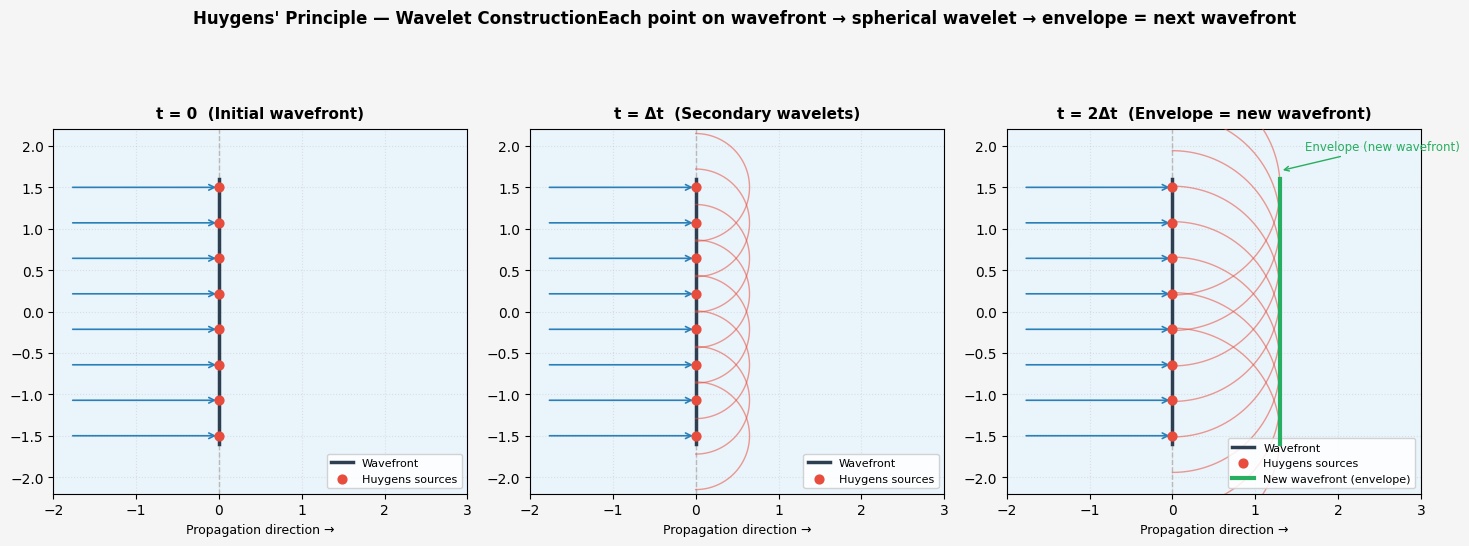

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  VISUALISATION 1: Huygens Wavelet Construction
# ─────────────────────────────────────────────────────────────────────────────
def plot_huygens_construction(n_sources=8, wavelet_radius=0.65):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
    fig.patch.set_facecolor('#f5f5f5')
    titles = ['t = 0  (Initial wavefront)',
              't = Δt  (Secondary wavelets)',
              't = 2Δt  (Envelope = new wavefront)']
    y_sources = np.linspace(-1.5, 1.5, n_sources)
    for col, ax in enumerate(axes):
        ax.set_facecolor('#eaf4fb')
        ax.set_xlim(-2.0, 3.0); ax.set_ylim(-2.2, 2.2)
        ax.set_aspect('equal')
        ax.set_title(titles[col], fontsize=11, fontweight='bold', pad=8)
        ax.axvline(0, color='#bbb', lw=1, linestyle='--', zorder=1)
        ax.set_xlabel('Propagation direction →', fontsize=9)
        for ys in y_sources:
            ax.annotate('', xy=(0, ys), xytext=(-1.8, ys),
                        arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.2))
        ax.plot([0,0],[-1.6,1.6], color='#2c3e50', lw=2.5, label='Wavefront', zorder=3)
        ax.scatter(np.zeros(n_sources), y_sources, s=40,
                   color='#e74c3c', zorder=5, label='Huygens sources')
        if col >= 1:
            r = wavelet_radius * col
            theta = np.linspace(-np.pi/2, np.pi/2, 200)
            for ys in y_sources:
                ax.plot(r*np.cos(theta), ys+r*np.sin(theta),
                        color='#e74c3c', lw=1.0, alpha=0.55, zorder=4)
        if col == 2:
            x_env = wavelet_radius * 2
            ax.plot([x_env,x_env],[-1.6,1.6],
                    color='#27ae60', lw=3, label='New wavefront (envelope)', zorder=6)
            ax.annotate('Envelope (new wavefront)', xy=(x_env, 1.7),
                        xytext=(x_env+0.3, 1.95), fontsize=8.5, color='#27ae60',
                        arrowprops=dict(arrowstyle='->', color='#27ae60'))
        ax.legend(fontsize=8, loc='lower right', framealpha=0.85)
        ax.grid(True, linestyle=':', alpha=0.3)
    fig.suptitle("Huygens' Principle — Wavelet Construction"
                 r"Each point on wavefront → spherical wavelet → envelope = next wavefront",
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

plot_huygens_construction()


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  SHARED DRAWING FUNCTION  — used by static plot AND interactive widget
#
#  Physical consistency rules:
#    1. Plane wavefronts (left)  : spaced by λ  (x < wall_x, full height)
#    2. Plane wavefronts (right) : spaced by λ  (x > wall_x, lit region y > edge_y only)
#    3. Huygens wavelet radii    : spaced by λ  (one wavelet per passing wavefront)
#       → all three spacings are identical → frequency slider affects ALL consistently
# ─────────────────────────────────────────────────────────────────────────────

def draw_diffraction_scene(ax, col, freq, t, n_src,
                            show_shad=True, show_env=True):

    wall_x   =  0.0
    edge_y   =  0.0
    wall_bot = -3.5
    lam = 0.65 / freq            # ← single wavelength used everywhere
    x_propagated = t * 2.8

    ax.set_facecolor('#eaf4fb')
    ax.set_xlim(-3.2, 3.5); ax.set_ylim(-3.2, 3.2)
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.25)

    # ── Wall ──
    ax.add_patch(FancyBboxPatch(
        (wall_x-0.09, wall_bot), 0.18, abs(wall_bot),
        boxstyle='square,pad=0', fc='#e74c3c', ec='#922b21', lw=2, zorder=8))
    ax.text(wall_x+0.15, wall_bot+0.15, 'Wall', ha='left',
            fontsize=9, color='#922b21', fontweight='bold', zorder=9)

    # ── LEFT: incident plane wavefronts (full height, x < wall_x) ──
    for x_wf in np.arange(-3.0, wall_x, lam):
        ax.plot([x_wf, x_wf], [-3.0, 3.0],
                color='#2c3e50', lw=1.3, alpha=0.55, zorder=3)

    # ── Incident ray arrows ──
    for yr in np.linspace(-2.6, 2.6, n_src):
        ax.annotate('', xy=(wall_x-0.12, yr), xytext=(wall_x-1.0, yr),
                    arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.1))

    if col == 0:
        # t=0: wavefront at wall, clipped above edge only
        ax.plot([wall_x, wall_x], [edge_y, 3.0],
                color='#27ae60', lw=2.5, zorder=6)
        ax.text(-1.9, 0.3, 'Incident wave', fontsize=9, color='#2c3e50',
                bbox=dict(fc='white', ec='#2c3e50', alpha=0.85, pad=2, boxstyle='round'))
        ax.set_title(f't = 0  |  λ_rel = {lam:.2f}  |  f_rel = {freq:.1f}',
                     fontsize=10, fontweight='bold')

    else:
        # ── RIGHT: propagated plane wavefronts in LIT region (y ≥ edge_y) ──
        # Spaced by λ — same as left side
        for x_wf in np.arange(lam, x_propagated + lam, lam):
            ax.plot([x_wf, x_wf], [edge_y, 3.0],
                    color='#2c3e50', lw=1.3, alpha=0.55, zorder=3)

        # Shadow region shading
        if show_shad:
            ax.fill_between([wall_x, 3.5], wall_bot, edge_y,
                            color='#bdc3c7', alpha=0.30, zorder=1)
            ax.plot([wall_x, 3.5], [edge_y, edge_y],
                    color='#7f8c8d', lw=1.5, linestyle='--', zorder=7)
            ax.text(2.2, -1.8, 'Shadow Region',
                    ha='center', fontsize=9, color='#636e72', style='italic')

        # ── Huygens wavelets: radii spaced by λ (key fix) ──
        # One wavelet is emitted each time a plane wavefront passes the edge.
        # The k-th wavelet (emitted k wavefronts ago) has radius = k * λ.
        # Outermost radius = x_propagated (emitted at t=0).
        wavelet_radii = np.arange(lam, x_propagated + lam, lam)

        theta_all = np.linspace(-np.pi, np.pi, 500)
        for r in wavelet_radii:
            xw = wall_x + r * np.cos(theta_all)
            yw = edge_y  + r * np.sin(theta_all)
            fwd    = xw >= wall_x
            lit    = fwd & (yw >= edge_y)
            shadow = fwd & (yw <  edge_y)
            if np.any(lit):
                ax.plot(xw[lit],    yw[lit],
                        color='#e74c3c', lw=1.0, alpha=0.50, zorder=5)
            if np.any(shadow):
                ax.plot(xw[shadow], yw[shadow],
                        color='#8e44ad', lw=0.9, alpha=0.45,
                        linestyle='--', zorder=5)

        # Diffraction edge marker
        ax.scatter([wall_x], [edge_y], s=55, color='#e74c3c', zorder=9)

        if show_env:
            # Lit wavefront: vertical line at x_propagated, above edge
            ax.plot([wall_x+x_propagated]*2, [edge_y, 3.1],
                    color='#27ae60', lw=3, zorder=6,
                    label='New wavefront (lit)')
            # Shadow wavefront: arc right → downward into shadow
            th = np.linspace(0, -np.pi/2, 120)
            xb = wall_x + x_propagated * np.cos(th)
            yb = edge_y  + x_propagated * np.sin(th)
            ax.plot(xb, yb, color='#8e44ad', lw=2.8,
                    linestyle='--', zorder=6, label='New wavefront (shadow)')
            mid = len(th)//2
            ax.annotate('',
                xy=(xb[mid]-0.15, yb[mid]-0.35),
                xytext=(xb[mid]+0.2, yb[mid]+0.1),
                arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=1.8))
            ax.text(xb[mid]+0.6, yb[mid]-1.0,
                    'New wave front\n in geometric shadow',
                    ha='center', fontsize=8.5, color='#8e44ad',
                    bbox=dict(fc='white', ec='#8e44ad', alpha=0.85,
                              pad=2.5, boxstyle='round'))

        ax.set_title(f't > 0  |  t = {t:.2f}  |  λ_rel = {lam:.2f}  |  '
                     f'N_wavelets = {len(wavelet_radii)}',
                     fontsize=10, fontweight='bold')
        ax.legend(fontsize=8.5, loc='upper right', framealpha=0.9)

print("✅ draw_diffraction_scene() defined.")


✅ draw_diffraction_scene() defined.


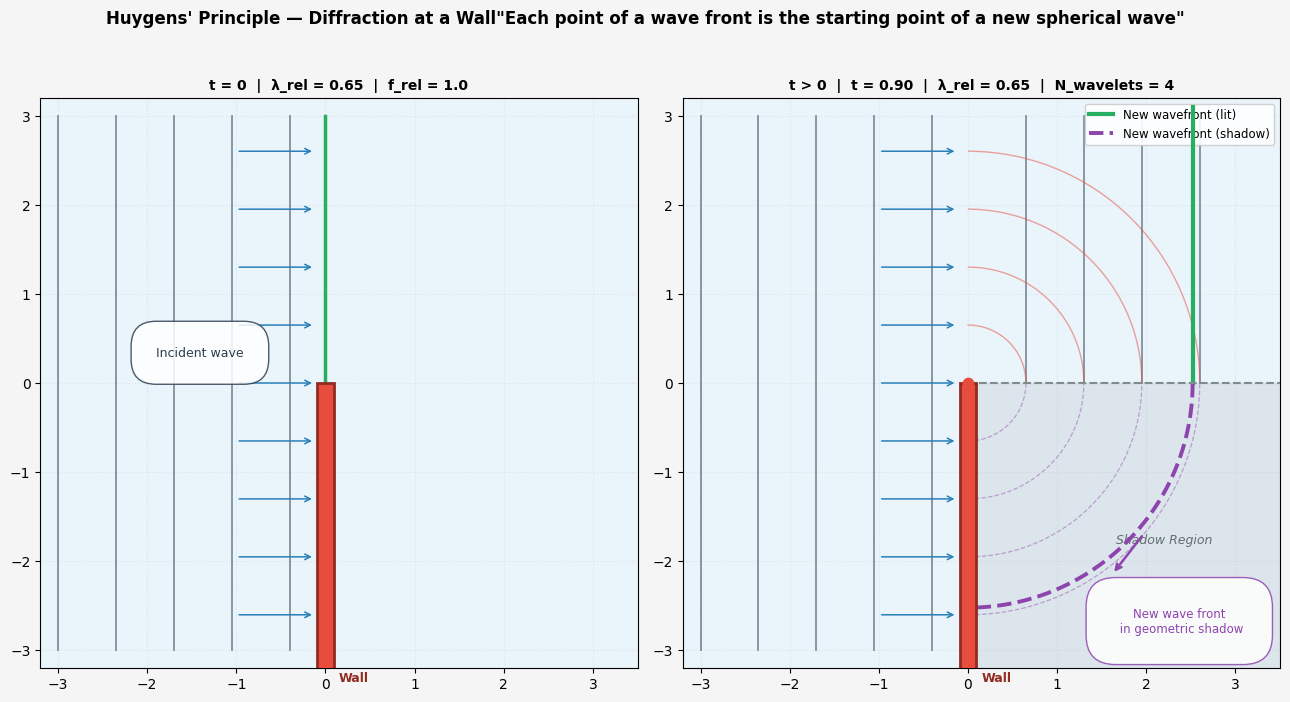

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  VISUALISATION 2: Static Diffraction at a Wall (default parameters)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.patch.set_facecolor('#f5f5f5')
draw_diffraction_scene(axes[0], col=0, freq=1.0, t=0.9,   n_src=9)
draw_diffraction_scene(axes[1], col=1, freq=1.0, t=0.9,   n_src=9)
fig.suptitle(
    "Huygens' Principle — Diffraction at a Wall"
    '"Each point of a wave front is the starting point of a new spherical wave"',
    fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  VISUALISATION 3: Interactive Diffraction Explorer
#
#  All three spacings now driven by the SAME λ = 0.65 / f_rel:
#    • Plane wavefronts LEFT  side  → spacing λ
#    • Plane wavefronts RIGHT side  → spacing λ  (lit region only)
#    • Huygens wavelet arcs         → radii at λ, 2λ, 3λ, ...  (shadow + lit)
#
#  N Huygens wavelets slider is REMOVED — count is now physically determined
#  by λ and t:  N_wavelets = floor(x_propagated / λ)
# ─────────────────────────────────────────────────────────────────────────────

style  = {'description_width': '170px'}
layout = widgets.Layout(width='470px')

sl_time    = widgets.FloatSlider(value=0.9, min=0.1, max=1.5, step=0.05,
    description='Time step (t):', style=style, layout=layout, readout_format='.2f')
sl_sources = widgets.IntSlider(value=8, min=3, max=15, step=1,
    description='N incident arrows:', style=style, layout=layout)
sl_freq    = widgets.FloatSlider(value=1.0, min=0.3, max=3.0, step=0.1,
    description='Relative frequency:', style=style, layout=layout, readout_format='.1f')
check_shadow = widgets.Checkbox(value=True,
    description='Show geometric shadow region',
    style={'description_width':'80px'})
check_env = widgets.Checkbox(value=True,
    description='Show new wavefront (envelope)',
    style={'description_width':'80px'})

out = widgets.Output()

def update(_=None):
    with out:
        clear_output(wait=True)
        t    = sl_time.value
        freq = sl_freq.value
        n_src = sl_sources.value
        lam  = 0.65 / freq
        n_wavelets = int(np.floor(t * 2.8 / lam))

        fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
        fig.patch.set_facecolor('#f5f5f5')
        draw_diffraction_scene(axes[0], col=0, freq=freq, t=t, n_src=n_src,
                               show_shad=check_shadow.value,
                               show_env=check_env.value)
        draw_diffraction_scene(axes[1], col=1, freq=freq, t=t, n_src=n_src,
                               show_shad=check_shadow.value,
                               show_env=check_env.value)
        fig.suptitle(
            "Huygens' Principle — Interactive Diffraction at a Wall"
            r'"Each point of a wave front is the starting point of a new spherical wave"',
            fontsize=11, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

        print(f"\n📐  f_rel = {freq:.1f}  →  λ_rel = {lam:.2f}")
        print(f"    Wavefront spacing (left  side) : {lam:.2f}  ← same λ")
        print(f"    Wavefront spacing (right side) : {lam:.2f}  ← same λ")
        print(f"    Huygens wavelet radii          : {lam:.2f}, {2*lam:.2f}, {3*lam:.2f} ... ← same λ")
        print(f"    N_wavelets auto = {n_wavelets}  (= floor({t*2.8:.2f} / {lam:.2f}))")

for sl in [sl_time, sl_sources, sl_freq]:
    sl.observe(update, names='value')
for cb in [check_shadow, check_env]:
    cb.observe(update, names='value')

hint = ("<h3>⚙️ Adjust Diffraction Parameters</h3>"
        "<p style='color:#555;font-size:13px'>"
        "🔑 <b>f_rel</b> now controls <b>all three spacings equally</b>:<br>"
        "&nbsp;&nbsp;① Incident wavefronts (left) &nbsp;"
        "&nbsp;② Propagated wavefronts (right, lit) &nbsp;"
        "&nbsp;③ Huygens diffraction arcs (shadow)<br>"
        "Try <b>f_rel = 0.3</b> vs <b>f_rel = 3.0</b> to see sparse vs dense arcs everywhere.</p>")

ui = widgets.VBox([
    widgets.HTML(hint),
    widgets.HBox([
        widgets.VBox([sl_time, sl_sources, sl_freq]),
        widgets.VBox([check_shadow, check_env])
    ]),
    out
])
display(ui)
update()


## 📚 Summary — Huygens' Principle in Mobile Communications

| Concept | Description | Effect on mobile signal |
|---------|-------------|------------------------|
| **Direct wavefront** | Plane wave, unobstructed above wall | Strong signal (LOS path) |
| **Diffraction edge** | Top of the wall — the Huygens point source | Origin of all diffracted waves |
| **Shadow wavefront** | Arc curving rightward then downward | Signal reaches shadow zone, but attenuated |
| **Frequency dependence** | Low freq (large λ) diffracts more | 700 MHz bends around buildings better than 3.5 GHz |

### Time step (*t*) 
It is a normalized propagation distance — how far the wave has traveled past the wall after the moment of diffraction.

| Value   | Meaning                                                 |
| ------- | ------------------------------------------------------- |
| t = 0   | Wave just arrived at the wall edge — no diffraction yet |
| t = 0.5 | Wave has traveled a short distance past the wall        |
| t = 1.5 | Wave has propagated far past the wall                   |

In the diagram, x_propagated = t × 2.8 — so t simply scales the radius of all Huygens wavelets and the position of the new wavefront. Think of it as a "movie frame slider" — moving it forward animates the wave propagating away from the wall.

### *N* Huygens Wavelets 
It is he number of concentric circular arcs drawn from the diffraction edge point (0, 0). Each arc represents a secondary wavelet at a different radius (i.e., emitted at a slightly different moment in time).

- Low value (3–4): Sparse, easier to see individual wavelets
- High value (12–15): Dense circles, clearly shows how they fill the shadow zone
- The outermost arc = the new wavefront (envelope), which is separately drawn in green/purple

### *N* Incident Arrows
The number of blue horizontal arrows drawn on the left side, representing the direction of propagation of the incoming plane wave. This is purely cosmetic — it does not change any physics.

- More arrows → denser visualization of the incident wave direction
- Useful for showing you that all rays arrive parallel and horizontal before hitting the wall

### Relative Frequency (f_rel)
Controls the spacing between the vertical incident wavefront lines on the left side:
$$
\lambda_{ref} = \frac{1}{f_{ref}}
$$

| f_rel | λ_rel | Visual effect                    | Physical analogy      |
| ----- | ----- | -------------------------------- | --------------------- |
| 0.3   | 3.3   | Wide spacing → long wavelength   | ~700 MHz (bends more) |
| 1.0   | 1.0   | Medium spacing                   | ~1800 MHz (reference) |
| 3.0   | 0.33  | Tight spacing → short wavelength | ~3.5 GHz (bends less) |

This is the most physically meaningful slider — it illustrates why lower frequencies diffract more around obstacles in mobile networks. The wavelet circles themselves don't change size (since t controls that), but the denser/sparser wavefront lines give you intuition about wavelength.


### Knife-Edge Diffraction Loss (Fresnel–Kirchhoff)

$$
L_{diff} \approx 6.02 + 9.11\,\nu + 1.27\,\nu^2 \quad [\text{dB}] \quad (\nu > 0)
$$

$$
\nu = h \sqrt{\frac{2(d_1+d_2)}{\lambda \, d_1 \, d_2}}
$$

- $h$ = obstacle height above LOS line, $d_1, d_2$ = Tx/Rx distances to obstacle, $\lambda$ = wavelength  
- Rule of thumb: $\nu > 2.4$ → loss $> 20$ dB (signal practically blocked)
